<a href="https://colab.research.google.com/github/changyunyeong/ComputerGraphics/blob/main/Linear_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time, platform, pickle, os

from tensorflow.keras.datasets import cifar10
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

np.random.seed(42)

In [11]:
# cs231n 코드 이용
def load_pickle(f):
    version = platform.python_version_tuple()
    if version[0] == "2":
        return pickle.load(f)
    elif version[0] == "3":
        return pickle.load(f, encoding="latin1")
    raise ValueError("invalid python version: {}".format(version))

def load_CIFAR_batch(filename):
    """ load single batch of cifar """
    with open(filename, "rb") as f:
        datadict = load_pickle(f)
        X = datadict["data"]
        Y = datadict["labels"]
        X = X.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1).astype("float")
        Y = np.array(Y)
        return X, Y

def load_CIFAR10(ROOT):
    """ load all of cifar """
    xs = []
    ys = []
    for b in range(1, 6):
        f = os.path.join(ROOT, "data_batch_%d" % (b,))
        X, Y = load_CIFAR_batch(f)
        xs.append(X)
        ys.append(Y)
    Xtr = np.concatenate(xs)
    Ytr = np.concatenate(ys)
    del X, Y
    Xte, Yte = load_CIFAR_batch(os.path.join(ROOT, "test_batch"))
    return Xtr, Ytr, Xte, Yte

In [12]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [13]:
Xtr, Ytr, Xte, Yte = load_CIFAR10('/content/')
num_train = 5000
num_test = 1000

# 5000 training images, 1000 test images
Xtr_small = Xtr[:num_train]
Ytr_small = Ytr[:num_train]

Xte_small = Xte[:num_test]
Yte_small = Yte[:num_test]

# flattern images from 32x32x3 to 3072 features
Xtr_rows = Xtr_small.reshape(num_train, 32*32*3).astype(np.int16)
Xte_rows = Xte_small.reshape(num_test, 32*32*3).astype(np.int16)

X_train = Xtr_rows.astype("float32") / 255.0
X_test = Xte_rows.astype("float32") / 255.0

y_train = Ytr_small
y_test = Yte_small

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3072,)),
    tf.keras.layers.Dense(10)   # linear classifier: Wx + b
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)


Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.1273 - loss: 19.5510 - val_accuracy: 0.1780 - val_loss: 15.5332
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1625 - loss: 14.6849 - val_accuracy: 0.1970 - val_loss: 15.1516
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1928 - loss: 12.8048 - val_accuracy: 0.1460 - val_loss: 14.1345
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2002 - loss: 10.8825 - val_accuracy: 0.2190 - val_loss: 9.3668
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2075 - loss: 11.8123 - val_accuracy: 0.1950 - val_loss: 14.1930
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2230 - loss: 10.3751 - val_accuracy: 0.2030 - val_loss: 10.6748
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2068 - loss: 11.1561 - val_accuracy: 0.1700 - val_loss: 13.9283
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2230 - loss: 11.4150 - val_accuracy: 0

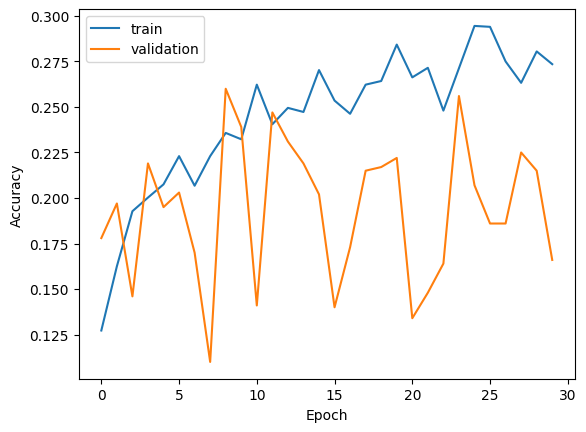

In [14]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay

def make_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(3072,)),
        tf.keras.layers.Dense(10)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )
    return model

# 5-Fold Cross Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    cv_model = make_model()

    cv_model.fit(
        X_train[train_idx], y_train[train_idx],
        epochs=30,
        batch_size=128,
        verbose=0
    )

    loss, acc = cv_model.evaluate(X_train[val_idx], y_train[val_idx], verbose=0)
    cv_scores.append(acc)
    print(f"Fold {fold} accuracy: {acc:.4f}")

print("Mean CV accuracy:", np.mean(cv_scores))
print("Std CV accuracy:", np.std(cv_scores))

Fold 1 accuracy: 0.2240
Fold 2 accuracy: 0.2500
Fold 3 accuracy: 0.2630
Fold 4 accuracy: 0.1910
Fold 5 accuracy: 0.1720
Mean CV accuracy: 0.2200000047683716
Std CV accuracy: 0.03438022832817438


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


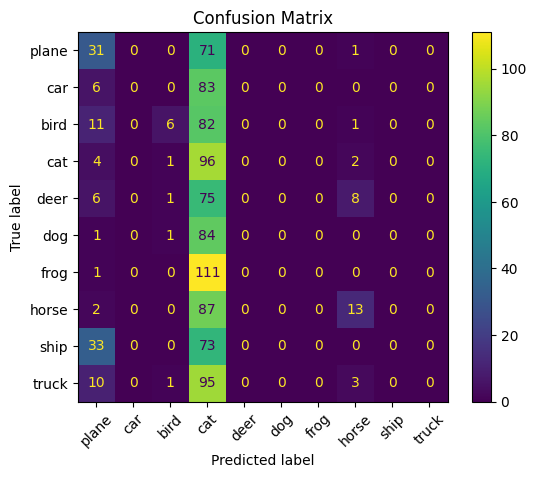

In [16]:
# Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()